In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive

In [6]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
origem = '/content/drive/My Drive/BASE PRF'

In [8]:
# Cria uma lista iterando pelos anos de 2017 a 2025
anos = range(2017, 2026)
caminhos_arquivos = [origem + f'/acidentes{ano}_todas_causas_tipos.csv' for ano in anos]

# Lê e concatena todos os arquivos CSV em um único DataFrame
df_sinistros = pd.concat([pd.read_csv(arquivo, encoding='latin1', sep=';', na_values=['NA']) for arquivo in caminhos_arquivos], ignore_index=True)

In [9]:
df_sinistros.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4069971 entries, 0 to 4069970
Data columns (total 37 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      float64
 1   pesid                   float64
 2   data_inversa            object 
 3   dia_semana              object 
 4   horario                 object 
 5   uf                      object 
 6   br                      float64
 7   km                      object 
 8   municipio               object 
 9   causa_principal         object 
 10  causa_acidente          object 
 11  ordem_tipo_acidente     int64  
 12  tipo_acidente           object 
 13  classificacao_acidente  object 
 14  fase_dia                object 
 15  sentido_via             object 
 16  condicao_metereologica  object 
 17  tipo_pista              object 
 18  tracado_via             object 
 19  uso_solo                object 
 20  id_veiculo              float64
 21  tipo_veiculo            object 

In [10]:
#Verifica se há linhas duplicadas de código
total_duplicadas = df_sinistros.duplicated().sum()
print(f"Total de linhas duplicadas encontradas: {total_duplicadas}")

Total de linhas duplicadas encontradas: 0


In [11]:

# Mostra apenas as colunas que têm algum valor nulo:
nulos_por_coluna = df_sinistros.isnull().sum()
print("\nColunas que possuem valores nulos:")
print(nulos_por_coluna[nulos_por_coluna > 0])


Colunas que possuem valores nulos:
pesid                     387071
br                         10090
km                         10090
tipo_acidente                 96
classificacao_acidente       123
id_veiculo                144908
tipo_veiculo              144908
ano_fabricacao_veiculo    144908
tipo_envolvido            387071
estado_fisico             387071
idade                     740269
sexo                      387071
ilesos                    387071
feridos_leves             387071
feridos_graves            387071
mortos                    387071
regional                     409
delegacia                   1905
uop                         4339
dtype: int64


In [12]:
#LIMPEZA DE DADOS E DIMENSÃO DA AMOSTRA

# 1. Armazena o número total de linhas antes da exclusão
total_antes = len(df_sinistros)

# 2. Executa a limpeza dos dados (considerando ausência de dados em colunas essenciais)
df_sinistros = df_sinistros.dropna(subset=['tipo_acidente', 'classificacao_acidente'])

# 3. Armazena o novo número total de linhas após a exclusão
total_depois = len(df_sinistros)

# 4. Calcula a porcentagem
porcentagem = (total_depois / total_antes) * 100

# Exibe o resultado formatado com duas casas decimais
print(f"Linhas originais: {total_antes}")
print(f"Linhas após limpeza: {total_depois}")
print(f"Porcentagem da base mantida para análise: {porcentagem:.2f}%")

Linhas originais: 4069971
Linhas após limpeza: 4069753
Porcentagem da base mantida para análise: 99.99%


In [13]:
# 1. Converte a coluna para o tipo data do Pandas
df_sinistros['data_inversa'] = pd.to_datetime(df_sinistros['data_inversa'])

# 2. Cria a nova coluna 'ano' extraindo apenas o ano da data
df_sinistros['ano'] = df_sinistros['data_inversa'].dt.year

# 3. Gera a estatística descritiva já com a soma de totais (linhas e colunas)
tabela_estado_ano = pd.crosstab(
    df_sinistros['uf'],
    df_sinistros['ano'],
    margins=True,
    margins_name='Total'
)

# 4. Altera os nomes dos eixos para melhor apresentação
tabela_estado_ano.index.name = 'UF'
tabela_estado_ano.columns.name = 'Ano'

# 5. Exibe o resultado na tela
print("Quantidade de sinistros por Estado e por Ano:")
display(tabela_estado_ano)

Quantidade de sinistros por Estado e por Ano:


Ano,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total
UF,,,,,,,,,,
AC,1078,1056,1042,1574,1433,1753,1924,2257,3124,15241
AL,3273,2952,2805,3156,2646,2918,3058,3718,3554,28080
AM,698,876,598,1948,1274,1089,1676,3375,1396,12930
AP,781,1022,634,1159,1212,1811,1004,1103,1700,10426
BA,18756,17178,18081,19306,26214,25792,32284,34879,33498,225988
CE,6831,8039,10042,9663,10479,9856,10848,11391,10489,87638
DF,4360,3697,5192,6628,6396,5617,8196,8831,7823,56740
ES,10992,9822,10181,10229,11100,10334,12385,15048,16134,106225
GO,18526,17211,17570,22315,26155,27264,27812,31927,30070,218850


In [14]:
# 1. Faz a contagem por estado (UF) e seleciona apenas os 5 primeiros
top5_estados = df_sinistros['uf'].value_counts().head(5)

# 2. Calcula a porcentagem usando a variável 'total_depois' que já foi criada lá em cima
porcentagem_top5 = (top5_estados / total_depois) * 100

# 3. Cria uma tabela (DataFrame) para exibir as duas informações juntas
df_resumo_top5 = pd.DataFrame({
    'Quantidade de Sinistros': top5_estados,
    'Representatividade (%)': porcentagem_top5.round(2)
})

df_resumo_top5.index.name = 'UF'

# Adiciona a linha 'Total' somando os valores
df_resumo_top5.loc['Total'] = df_resumo_top5.sum()

print("Top 5 estados com mais sinistros no período e sua representatividade:")
display(df_resumo_top5)

Top 5 estados com mais sinistros no período e sua representatividade:


,Quantidade de Sinistros,Representatividade (%)
UF,,
MG,561817.0,13.80
PR,470758.0,11.57
SC,372145.0,9.14
RS,282566.0,6.94
SP,262781.0,6.46
Total,1950067.0,47.91


In [15]:
# Conta as ocorrências para todas as causas registradas
todas_causas = df_sinistros['causa_acidente'].value_counts().head(10)

# Calcula a porcentagem em relação ao total de sinistros
porcentagem_causas_total = (todas_causas / total_depois) * 100

# Cria a tabela para exibir os dados estruturados
df_todas_causas = pd.DataFrame({
    'Quantidade de Sinistros': todas_causas,
    'Representatividade (%)': porcentagem_causas_total.round(2)
})

# Renomeia o índice para melhor apresentação
df_todas_causas.index.name = 'Causa do Acidente'

# Adiciona a linha de Total no final
df_todas_causas.loc['Total'] = df_todas_causas.sum()

print("Quantidade total de sinistros por cada causa registrada:")
display(df_todas_causas)

Quantidade total de sinistros por cada causa registrada:


,Quantidade de Sinistros,Representatividade (%)
Causa do Acidente,,
Falta de Atenção à Condução,454286.0,11.16
Velocidade Incompatível,441213.0,10.84
Reação tardia ou ineficiente do condutor,366928.0,9.02
Ausência de reação do condutor,293816.0,7.22
Condutor deixou de manter distância do veículo da frente,190265.0,4.68
Acessar a via sem observar a presença dos outros veículos,177731.0,4.37
Desobediência às normas de trânsito pelo condutor,159849.0,3.93
Manobra de mudança de faixa,147482.0,3.62
Ingestão de álcool pelo condutor,135840.0,3.34


In [16]:
# Conta as ocorrências para cada tipo de veículo
contagem_veiculos = df_sinistros['tipo_veiculo'].value_counts()

# Cria a tabela (DataFrame) para exibir os dados estruturados
df_tipos_veiculo = pd.DataFrame({
    'Quantidade de Veículos': contagem_veiculos
})

# Renomeia o índice para melhor apresentação
df_tipos_veiculo.index.name = 'Tipo de Veículo'

# Adiciona a linha de Total no final
df_tipos_veiculo.loc['Total'] = df_tipos_veiculo.sum()

# Exibe o resultado no ecrã
print("Quantidade de veículos envolvidos por tipo:")
display(df_tipos_veiculo)

Quantidade de veículos envolvidos por tipo:


,Quantidade de Veículos
Tipo de Veículo,
Automóvel,1454632
Motocicleta,706581
Semireboque,345628
Caminhonete,341430
Caminhão-trator,299708
Caminhão,245039
Ônibus,177882
Camioneta,94397
Motoneta,74251


In [17]:
# 1. Conta as ocorrências para cada classificação de acidente

contagem_classificacao = df_sinistros['classificacao_acidente'].value_counts(dropna=False)

# 2. Calcula a proporção (porcentagem) em relação ao total de acidentes

total_acidentes = len(df_sinistros)
proporcao_classificacao = (contagem_classificacao / total_acidentes) * 100

# 3. Cria a tabela (DataFrame) para exibir os dados lado a lado
df_classificacao = pd.DataFrame({
    'Quantidade de Acidentes': contagem_classificacao,
    'Proporção (%)': proporcao_classificacao.round(4)
})

# 4. Renomeia o índice para ficar mais claro na exibição
df_classificacao.index.name = 'Classificação do Acidente'

# 5. Adiciona a linha com a soma total no final da tabela
df_classificacao.loc['Total'] = df_classificacao.sum()

# 6. Exibe o resultado na tela
print("Comparação e proporção de acidentes por classificação:")
display(df_classificacao)

Comparação e proporção de acidentes por classificação:


,Quantidade de Acidentes,Proporção (%)
Classificação do Acidente,,
Com Vítimas Feridas,2948876.0,72.4584
Com Vítimas Fatais,607069.0,14.9166
Sem Vítimas,513808.0,12.6250
Total,4069753.0,100.0000


In [18]:
# 1. Agrupa os dados por tipo de veículo e calcula totais
analise_letalidade = df_sinistros.groupby('tipo_veiculo').agg(
    Total_Acidentes=('id', 'count'), # Conta o número de linhas (acidentes)
    Total_Mortos=('mortos', 'sum')   # Soma a quantidade de mortes
)

# 2. Filtra para manter apenas veículos com relevância estatística (ex: mais de 1000 acidentes no período)
# Isso evita que um tipo de veículo raro com 1 acidente e 1 morte apareça com 100% de letalidade
analise_letalidade = analise_letalidade[analise_letalidade['Total_Acidentes'] > 1000]

# 3. Calcula a Taxa de Letalidade (Mortos a cada 100 acidentes)
analise_letalidade['Taxa_Letalidade (%)'] = (analise_letalidade['Total_Mortos'] / analise_letalidade['Total_Acidentes']) * 100

# 4. Ordena a tabela pelos veículos mais letais no topo
analise_letalidade = analise_letalidade.sort_values('Taxa_Letalidade (%)', ascending=False).round(2)

print("Taxa de Letalidade por Tipo de Veículo (mínimo de 1000 ocorrências):")
display(analise_letalidade)

Taxa de Letalidade por Tipo de Veículo (mínimo de 1000 ocorrências):


,Total_Acidentes,Total_Mortos,Taxa_Letalidade (%)
tipo_veiculo,,,
Bicicleta,40470,5854.0,14.47
Ciclomotor,8613,803.0,9.32
Motocicleta,706581,55923.0,7.91
Carroça-charrete,1436,87.0,6.06
Motoneta,74251,4138.0,5.57
Micro-ônibus,33016,1795.0,5.44
Caminhão,245039,9986.0,4.08
Caminhão-trator,299708,11763.0,3.92
Caminhonete,341430,12808.0,3.75


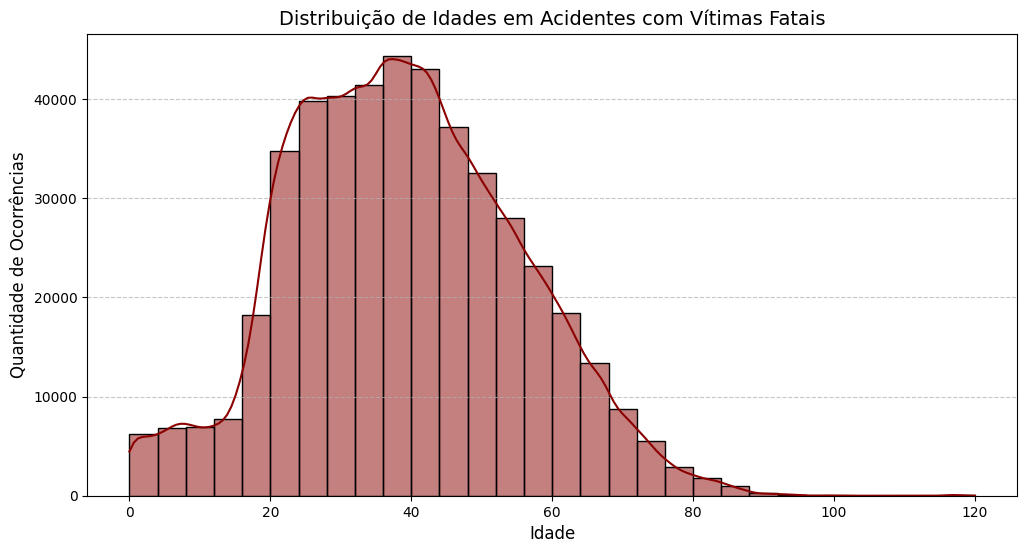

In [19]:
# 1. Filtra a base: apenas acidentes fatais E onde a idade foi preenchida
df_fatais = df_sinistros[(df_sinistros['classificacao_acidente'] == 'Com Vítimas Fatais') & (df_sinistros['idade'].notna())].copy()

# 2. Garante que a coluna idade seja tratada como número (forçando conversão de possíveis erros de texto para nulo)
df_fatais['idade'] = pd.to_numeric(df_fatais['idade'], errors='coerce')

# 3. Remove idades irreais (ex: erros de digitação maiores que 120 anos)
df_fatais = df_fatais[(df_fatais['idade'] >= 0) & (df_fatais['idade'] <= 120)]

# 4. Configura e plota o gráfico
plt.figure(figsize=(12, 6))
sns.histplot(data=df_fatais, x='idade', bins=30, kde=True, color='darkred', edgecolor='black')

# 5. Adiciona rótulos para melhor visualização
plt.title('Distribuição de Idades em Acidentes com Vítimas Fatais', fontsize=14)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Quantidade de Ocorrências', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [20]:
# 1. Trata os nulos reais (NaN) substituindo por uma categoria padrão
serie_sexo = df_sinistros['sexo'].fillna('Não Informado / Ignorado')

# 2. Substitui os textos que representam ausência de informação pela mesma categoria
# (Incluí variações de maiúsculas/minúsculas comuns em bases públicas)
termos_para_agrupar = ['Ignorado', 'Não Informado', 'Não informado', 'NA']
serie_sexo = serie_sexo.replace(termos_para_agrupar, 'Não Informado / Ignorado')

# 3. Conta as ocorrências já com as categorias consolidadadas
contagem_sexo = serie_sexo.value_counts()

# 4. Calcula a proporção
proporcao_sexo = (contagem_sexo / len(df_sinistros)) * 100

# 5. Cria a tabela (DataFrame)
df_sexo = pd.DataFrame({
    'Quantidade de Envolvidos': contagem_sexo,
    'Proporção (%)': proporcao_sexo.round(2)
})

# 6. Renomeia o índice e adiciona a linha de total
df_sexo.index.name = 'Sexo'
df_sexo.loc['Total'] = df_sexo.sum()

# 7. Exibe o resultado
print("Comparativo de envolvidos em sinistros por sexo :")
display(df_sexo)

Comparativo de envolvidos em sinistros por sexo :


,Quantidade de Envolvidos,Proporção (%)
Sexo,,
Masculino,2578645.0,63.36
Feminino,848070.0,20.84
Não Informado / Ignorado,643038.0,15.80
Total,4069753.0,100.00


In [21]:
# 1. Cria uma coluna que marca '1' se houve vítima fatal e '0' caso contrário
df_sinistros['eh_fatal'] = (df_sinistros['classificacao_acidente'] == 'Com Vítimas Fatais').astype(int)

# 2. Agrupa por Estado (uf) e Rodovia (br), somando os acidentes
analise_rodovias = df_sinistros.groupby(['uf', 'br']).agg(
    Total_Acidentes=('id', 'count'),       # Conta o total de acidentes
    Acidentes_Fatais=('eh_fatal', 'sum')   # Soma apenas os acidentes fatais
).reset_index()

# 3. Calcula a Taxa de Fatalidade (proporção de fatais em relação ao total)
analise_rodovias['Taxa_Fatalidade (%)'] = (analise_rodovias['Acidentes_Fatais'] / analise_rodovias['Total_Acidentes']) * 100

# 4. Remove possíveis registros sem identificação de rodovia
analise_rodovias = analise_rodovias.dropna(subset=['br'])

# 5. Formata a coluna BR para texto padrão (ex: de 116.0 para 'BR-116')
analise_rodovias['br'] = analise_rodovias['br'].apply(lambda x: f"BR-{int(x)}")

# 6. Ordena as 10 rodovias mais fatais em números absolutos
top10_rodovias = analise_rodovias.sort_values(by='Acidentes_Fatais', ascending=False).head(10)

# 7. Arredonda a taxa para 2 casas decimais e ajusta o nome das colunas
top10_rodovias['Taxa_Fatalidade (%)'] = top10_rodovias['Taxa_Fatalidade (%)'].round(2)
top10_rodovias = top10_rodovias.rename(columns={'uf': 'Estado', 'br': 'Rodovia'})

# Define o índice para começar de 1 a 10 em vez de manter o índice original bagunçado
top10_rodovias.index = range(1, 11)

display(top10_rodovias)

,Estado,Rodovia,Total_Acidentes,Acidentes_Fatais,Taxa_Fatalidade (%)
1,PR,BR-277,133958,21396,15.97
2,MG,BR-381,163329,19389,11.87
3,MG,BR-40,119871,17649,14.72
4,RO,BR-364,103056,15913,15.44
5,SP,BR-116,188830,15419,8.17
6,MG,BR-116,72512,14738,20.32
7,PR,BR-376,108884,13924,12.79
8,MT,BR-163,70863,13852,19.55
9,BA,BR-101,50108,12738,25.42
10,SC,BR-101,172897,12048,6.97


In [22]:
# 1. Agrupa os dados por Estado (UF), contando o total e somando os fatais
analise_estado = df_sinistros.groupby('uf').agg(
    Total_Acidentes=('id', 'count'),
    Acidentes_Fatais=('eh_fatal', 'sum')
)

# 2. Calcula a Taxa de Fatalidade média por estado (em porcentagem)
analise_estado['Taxa_Fatalidade (%)'] = (analise_estado['Acidentes_Fatais'] / analise_estado['Total_Acidentes']) * 100

# 3. Ordena a tabela pelos estados com a maior taxa de fatalidade
analise_estado = analise_estado.sort_values(by='Taxa_Fatalidade (%)', ascending=False).round(2)

# 4. Renomeia o índice para melhor apresentação
analise_estado.index.name = 'Estado'

# Exibe o resultado na tela
print("Média de fatalidade (taxa) por Estado:")
display(analise_estado)

Média de fatalidade (taxa) por Estado:


,Total_Acidentes,Acidentes_Fatais,Taxa_Fatalidade (%)
Estado,,,
PA,100054,27096,27.08
MA,85711,21147,24.67
BA,225988,50573,22.38
TO,56847,12264,21.57
PI,98655,20190,20.47
RR,12799,2489,19.45
MT,173622,32703,18.84
GO,218850,38955,17.80
AL,28080,4938,17.59


In [23]:
# =====================================================================
# ANÁLISE 1: Quantidade de Acidentes Fatais por Clima
# =====================================================================

# 1. Filtra a base para manter apenas os acidentes com vítimas fatais
df_fatais = df_sinistros[df_sinistros['classificacao_acidente'] == 'Com Vítimas Fatais']

# 2. Conta as ocorrências agrupadas por condição meteorológica
contagem_fatais_clima = df_fatais['condicao_metereologica'].value_counts()

# 3. Cria a tabela (DataFrame)
df_tabela_clima = pd.DataFrame({
    'Acidentes Fatais': contagem_fatais_clima
})

# 4. Ajusta os nomes e adiciona a linha de Total
df_tabela_clima.index.name = 'Condição Meteorológica'
df_tabela_clima.loc['Total'] = df_tabela_clima.sum()

print("Quantidade de Acidentes Fatais por Clima:")
display(df_tabela_clima)

print("\n" + "="*60 + "\n")

Quantidade de Acidentes Fatais por Clima:


,Acidentes Fatais
Condição Meteorológica,
Céu Claro,366277
Nublado,92783
Chuva,69728
Sol,31418
Garoa/Chuvisco,24719
Nevoeiro/Neblina,10741
Ignorado,10461
Vento,940
Granizo,2


In [24]:
destino = '/content/drive/MyDrive/CSV'

# 3. Executa a exportação (mantive as configurações de segurança para arquivos grandes e acentuação)
df_sinistros.to_csv(destino + '/' + 'base_prf_consolidada_bruta.csv', index=False, sep=';', encoding='utf-8-sig', chunksize=100000)

print("Arquivo exportado com sucesso direto para a pasta CSV no seu Google Drive!")

Arquivo exportado com sucesso direto para a pasta CSV no seu Google Drive!
